# **UTS Data Mining (Prediksi Kualitas Wine)**
Identitas Tugas
Mata Kuliah: Data Mining

Topik: Klasifikasi Kualitas Wine

Dataset: Wine Quality Dataset

##**1. Pendahuluan**
Pada tugas ini dilakukan pembuatan model klasifikasi untuk memprediksi kualitas wine berdasarkan karakteristik kimiawi yang dimiliki oleh wine. Variabel target yang diprediksi adalah quality.

Tahapan yang dilakukan meliputi:

1. Import library

2. Load dataset

3. Exploratory Data Analysis (EDA)

4. Data preprocessing

5. Feature scaling

6. Pembuatan beberapa model klasifikasi
7. Evaluasi dan perbandingan model
8. Pemilihan model terbaik
9. Prediksi data testing
10. Export hasil prediksi ke CSV

## **2. Import Library**

In [6]:
import pandas as pd
import numpy as np

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Model
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

# Evaluasi
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# Ignore warning
import warnings
warnings.filterwarnings('ignore')

**Penjelasan**

Library yang digunakan meliputi:


*   pandas dan numpy untuk pengolahan data.
*   matplotlib dan seaborn untuk visualisasi.


*   sklearn untuk preprocessing, pembuatan model, dan evaluasi.








## **3. Load Dataset**

In [7]:
# Load dataset training
train = pd.read_csv('/content/data_training.csv')

# Load dataset testing
test = pd.read_csv('/content/data_testing.csv')


In [ ]:
# Menampilkan 5 data pertama
train.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.3,0.740,0.08,1.7,0.094,10.0,45.0,0.99576,3.24,0.50,9.8,5,1366
1,8.1,0.575,0.22,2.1,0.077,12.0,65.0,0.99670,3.29,0.51,9.2,5,103
2,10.1,0.430,0.40,2.6,0.092,13.0,52.0,0.99834,3.22,0.64,10.0,7,942
3,12.9,0.500,0.55,2.8,0.072,7.0,24.0,1.00012,3.09,0.68,10.9,6,811
4,8.4,0.360,0.32,2.2,0.081,32.0,79.0,0.99640,3.30,0.72,11.0,6,918


In [8]:
# Melihat ukuran dataset
print('Ukuran data training:', train.shape)
print('Ukuran data testing:', test.shape)

Ukuran data training: (857, 13)
Ukuran data testing: (286, 12)


**Interpretasi**

*   Dataset training digunakan untuk melatih model karena memiliki variabel target quality.
*   Dataset testing digunakan untuk prediksi akhir karena belum memiliki label kualitas.

Berdasarkan hasil output, dataset training berhasil dimuat dengan ukuran sebanyak 857 baris dan 13 kolom, sedangkan dataset testing memiliki 286 baris dan 12 kolom.

Perbedaan jumlah kolom tersebut terjadi karena dataset training memiliki variabel target quality, sedangkan dataset testing tidak memiliki variabel tersebut karena digunakan untuk proses prediksi.

Selain itu, tampilan 5 data pertama menunjukkan bahwa dataset berisi beberapa variabel kimiawi wine, seperti:

fixed acidity,
volatile acidity,
citric acid,
residual sugar,
chlorides,
dan variabel lainnya

yang nantinya digunakan sebagai fitur untuk memprediksi kualitas wine (quality).

Dataset berhasil dibaca dengan baik sehingga proses analisis dapat dilanjutkan ke tahap preprocessing dan pemodelan machine learning.



## **4. Exploratory Data Analysis (EDA)**

### **4.1 Informasi Dataset**

In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 857 entries, 0 to 856
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         857 non-null    float64
 1   volatile acidity      857 non-null    float64
 2   citric acid           857 non-null    float64
 3   residual sugar        857 non-null    float64
 4   chlorides             857 non-null    float64
 5   free sulfur dioxide   857 non-null    float64
 6   total sulfur dioxide  857 non-null    float64
 7   density               857 non-null    float64
 8   pH                    857 non-null    float64
 9   sulphates             857 non-null    float64
 10  alcohol               857 non-null    float64
 11  quality               857 non-null    int64  
 12  Id                    857 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 87.2 KB


**Interpretasi**

Informasi dataset digunakan untuk mengetahui:


*  Jumlah data
*   Tipe data setiap variabel
*   Apakah terdapat missing value

Berdasarkan output train.info(), dataset training memiliki 857 data (entries) dengan total 13 variabel (columns).

Seluruh variabel memiliki jumlah 857 non-null, yang menunjukkan bahwa tidak terdapat missing value pada dataset training. Dengan demikian, data sudah lengkap sehingga tidak diperlukan penanganan missing value seperti imputasi ataupun penghapusan data.

Tipe data pada dataset terdiri dari:

float64 sebanyak 11 variabel, yaitu variabel numerik berbentuk desimal seperti fixed acidity, alcohol, dan pH.
int64 sebanyak 2 variabel, yaitu quality dan Id.

Variabel quality merupakan variabel target yang akan diprediksi, sedangkan variabel Id hanya digunakan sebagai identitas data dan tidak digunakan dalam proses pemodelan.

Karena seluruh fitur berupa data numerik, dataset ini sudah sesuai untuk digunakan pada algoritma machine learning klasifikasi seperti Logistic Regression, Random Forest, maupun model klasifikasi lainnya.

### **4.2 Statistik Deskriptif**

In [ ]:
train.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000
mean,8.261960,0.529393,0.267351,2.506184,0.086830,15.782964,45.978413,0.996692,3.313092,0.656709,10.430338,5.653442,813.749125
std,1.701992,0.179162,0.195144,1.293512,0.048721,10.300402,31.692113,0.001901,0.152079,0.167364,1.066971,0.821777,463.807063
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.390000,8.400000,3.000000,0.000000
25%,7.100000,0.395000,0.090000,1.900000,0.070000,7.000000,21.000000,0.995520,3.210000,0.550000,9.500000,5.000000,413.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,14.000000,38.000000,0.996680,3.310000,0.620000,10.200000,6.000000,814.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,63.000000,0.997800,3.400000,0.730000,11.100000,6.000000,1214.000000
max,15.600000,1.580000,1.000000,15.500000,0.611000,68.000000,278.000000,1.003200,4.010000,2.000000,14.000000,8.000000,1597.000000


**Interpretasi**

Berdasarkan output train.describe(), seluruh variabel memiliki jumlah data (count) sebanyak 857, sehingga menunjukkan bahwa tidak terdapat data yang hilang (missing value) pada dataset.

Statistik deskriptif memberikan informasi mengenai persebaran data seperti:

1. nilai rata-rata (mean),
2. standar deviasi (std),
3. nilai minimum (min),
4. kuartil,
5. dan nilai maksimum (max).

Beberapa interpretasi dari hasil tersebut antara lain:

1. Variabel fixed acidity memiliki rata-rata sebesar 8.26 dengan nilai minimum 4.6 dan maksimum 15.6, yang menunjukkan variasi tingkat keasaman tetap pada wine.
2. Variabel volatile acidity memiliki rata-rata 0.53. Nilai yang terlalu tinggi pada variabel ini dapat mempengaruhi kualitas wine karena berhubungan dengan rasa asam yang berlebihan.
3. Variabel citric acid memiliki rata-rata sebesar 0.27 dengan nilai maksimum 1.00, yang menunjukkan kandungan asam sitrat pada wine cukup bervariasi.
4. Variabel residual sugar memiliki rata-rata 2.51 dengan nilai maksimum mencapai 15.5, sehingga menunjukkan adanya perbedaan kadar gula antar sampel wine.
5. Variabel chlorides memiliki rata-rata relatif kecil yaitu 0.087, namun terdapat nilai maksimum 0.611 yang menunjukkan kemungkinan adanya data ekstrem atau outlier.
6. Variabel free sulfur dioxide dan total sulfur dioxide memiliki rentang nilai yang cukup besar sehingga menunjukkan variasi kandungan sulfur dioksida pada wine.

Selain itu, perbedaan nilai minimum dan maksimum yang cukup jauh pada beberapa variabel menunjukkan bahwa skala data antar fitur berbeda. Oleh karena itu, feature scaling diperlukan terutama untuk model seperti Logistic Regression dan KNN agar performa model menjadi lebih optimal.

### **4.3 Mengecek Missing Value**

In [ ]:
train.isnull().sum()
test.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


**Interpretasi**

Seluruh nilai bernilai 0, maka dataset tidak memiliki missing value sehingga tidak diperlukan imputasi data.

### **4.4 Distribusi Variabel Target**

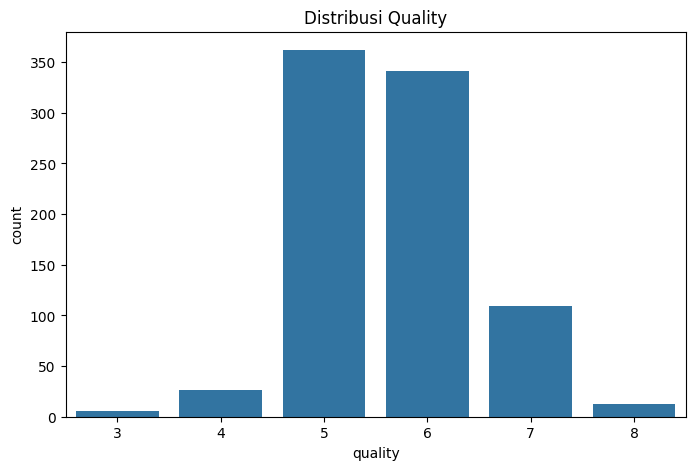

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='quality', data=train)
plt.title('Distribusi Quality')
plt.show()

**Interpretasi**

Grafik menunjukkan distribusi jumlah data pada setiap kategori quality.
Kategori dengan jumlah paling banyak menunjukkan kualitas wine yang paling sering muncul pada dataset.

### **4.5 Korelasi Antar Variabel**

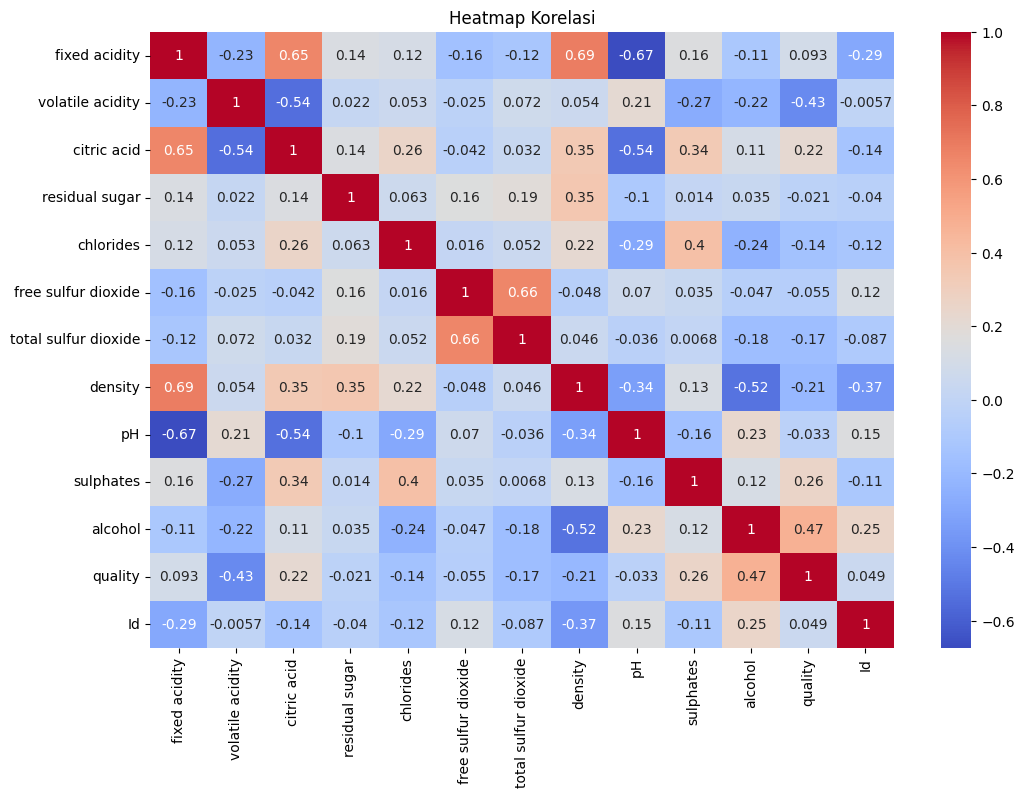

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(train.corr(), annot=True, cmap='coolwarm')
plt.title('Heatmap Korelasi')
plt.show()

**Interpretasi**

Heatmap digunakan untuk melihat hubungan antar variabel.

1. Nilai mendekati 1 menunjukkan korelasi positif kuat.
2. Nilai mendekati -1 menunjukkan korelasi negatif kuat.
3. Nilai mendekati 0 menunjukkan hubungan lemah.

Variabel dengan korelasi tinggi terhadap quality dapat memberikan pengaruh besar terhadap hasil prediksi.

Berdasarkan Output Heatmap korelasi menunjukkan hubungan antarvariabel pada data wine dengan nilai korelasi antara -1 hingga 1. Warna merah menunjukkan korelasi positif, sedangkan biru menunjukkan korelasi negatif.

Beberapa hubungan yang cukup kuat yaitu *fixed acidity* dengan *density* (0,69) dan *citric acid* (0,65), serta *free sulfur dioxide* dengan *total sulfur dioxide* (0,66). Korelasi negatif kuat terlihat pada *fixed acidity* dengan *pH* (-0,67), yang berarti semakin tinggi keasaman maka pH semakin rendah. Selain itu, *density* dan *alcohol* memiliki korelasi negatif sebesar -0,52.

Pada variabel *quality*, korelasi positif tertinggi terdapat pada *alcohol* (0,47), sehingga kadar alkohol yang lebih tinggi cenderung meningkatkan kualitas wine. Sebaliknya, *volatile acidity* memiliki korelasi negatif cukup kuat terhadap *quality* (-0,43), yang menunjukkan bahwa semakin tinggi *volatile acidity*, kualitas wine cenderung menurun. Secara keseluruhan, sebagian besar variabel memiliki hubungan lemah hingga sedang, namun *alcohol* dan *volatile acidity* merupakan variabel yang paling berpengaruh terhadap kualitas wine.


## **5. Data Preprocessing**

### **5.1 Memisahkan Fitur dan Target**

In [9]:
X = train.drop('quality', axis=1)
y = train['quality']

**Penjelasan**

*   X berisi variabel prediktor.
*   y berisi variabel target yaitu quality.






### **5.2 Split Data Training dan Validation**

In [10]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

**Interpretasi**

Dataset dibagi menjadi:


*   80% data training
*   20% data validation

Tujuannya agar model dapat diuji pada data yang belum pernah dilihat sebelumnya.

### **5.3 Feature Scaling**

In [11]:
scaler = StandardScaler()

# Drop 'Id' from X_train before fitting the scaler
X_train_no_id = X_train.drop('Id', axis=1)
X_train_scaled = scaler.fit_transform(X_train_no_id)

# Drop 'Id' from X_valid before transforming
X_valid_no_id = X_valid.drop('Id', axis=1)
X_valid_scaled = scaler.transform(X_valid_no_id)

# The test data already has 'Id' dropped as intended
X_test_scaled = scaler.transform(test.drop('Id', axis=1))

**Interpretasi**

Feature scaling dilakukan agar seluruh fitur memiliki skala yang seimbang.

Hal ini penting terutama pada model:

1. Logistic Regression
2. KNN

Karena model tersebut sensitif terhadap perbedaan skala data.

### **5.4 Distribusi Setiap Fitur**

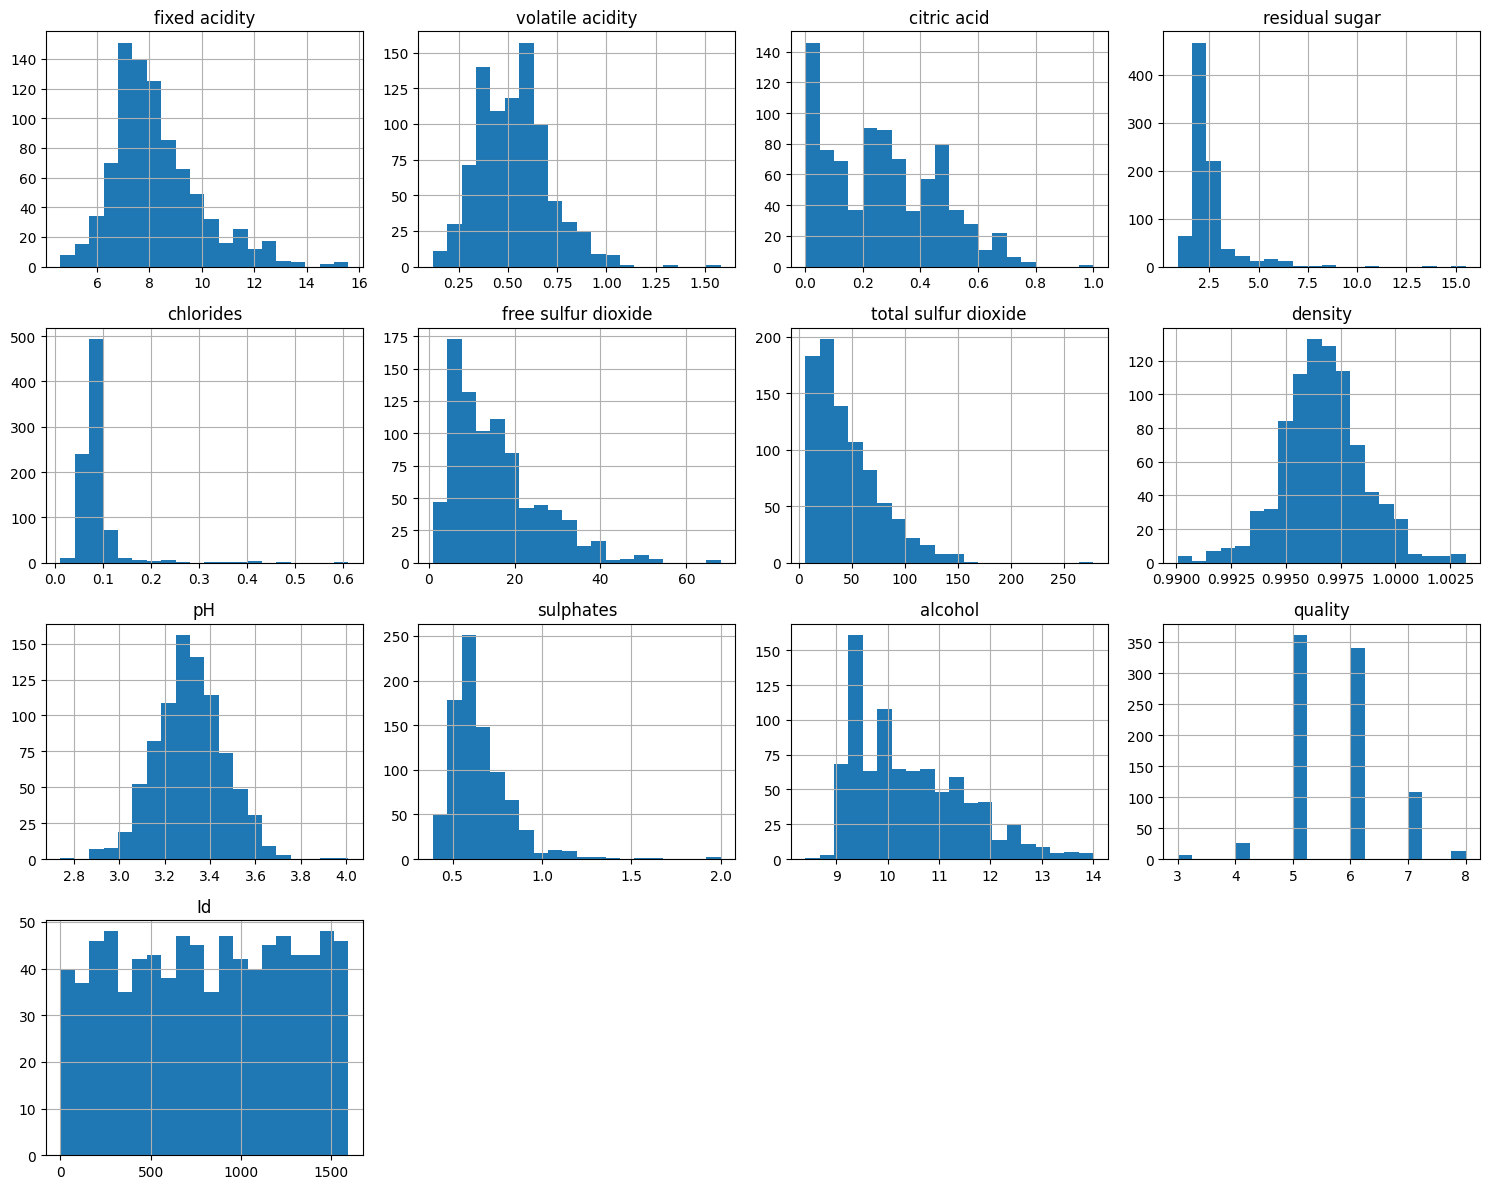

In [ ]:
train.hist(figsize=(15,12), bins=20)
plt.tight_layout()
plt.show()

**Interpretasi**

Visualisasi histogram digunakan untuk melihat persebaran data pada setiap variabel.

Dari grafik dapat diketahui:

1. apakah data berdistribusi normal,
2. apakah terdapat skewness,
3. dan apakah terdapat kemungkinan outlier.

Histogram distribusi fitur menunjukkan bahwa sebagian besar variabel memiliki distribusi yang tidak sepenuhnya normal dan cenderung miring ke kanan (*right skewed*). Variabel seperti *residual sugar*, *chlorides*, *free sulfur dioxide*, *total sulfur dioxide*, dan *sulphates* memiliki ekor panjang di sisi kanan, yang menandakan adanya beberapa nilai tinggi atau outlier.

Sementara itu, variabel *density* dan *pH* terlihat lebih mendekati distribusi normal karena bentuk histogramnya relatif simetris. Variabel *fixed acidity* dan *alcohol* juga memiliki distribusi yang cukup terpusat meskipun masih sedikit miring ke kanan.

Pada variabel target *quality*, data paling banyak berada pada nilai 5 dan 6, sehingga kualitas wine dalam dataset didominasi oleh kategori sedang. Sedangkan variabel *Id* tersebar merata karena hanya berfungsi sebagai penanda data dan tidak memiliki pola distribusi khusus.

Secara keseluruhan, distribusi data menunjukkan adanya beberapa variabel yang mengandung outlier dan tidak berdistribusi normal, sehingga pada tahap pemodelan dapat dipertimbangkan normalisasi atau transformasi data untuk meningkatkan performa model.


### **5.5 Boxplot Deteksi Outlier**

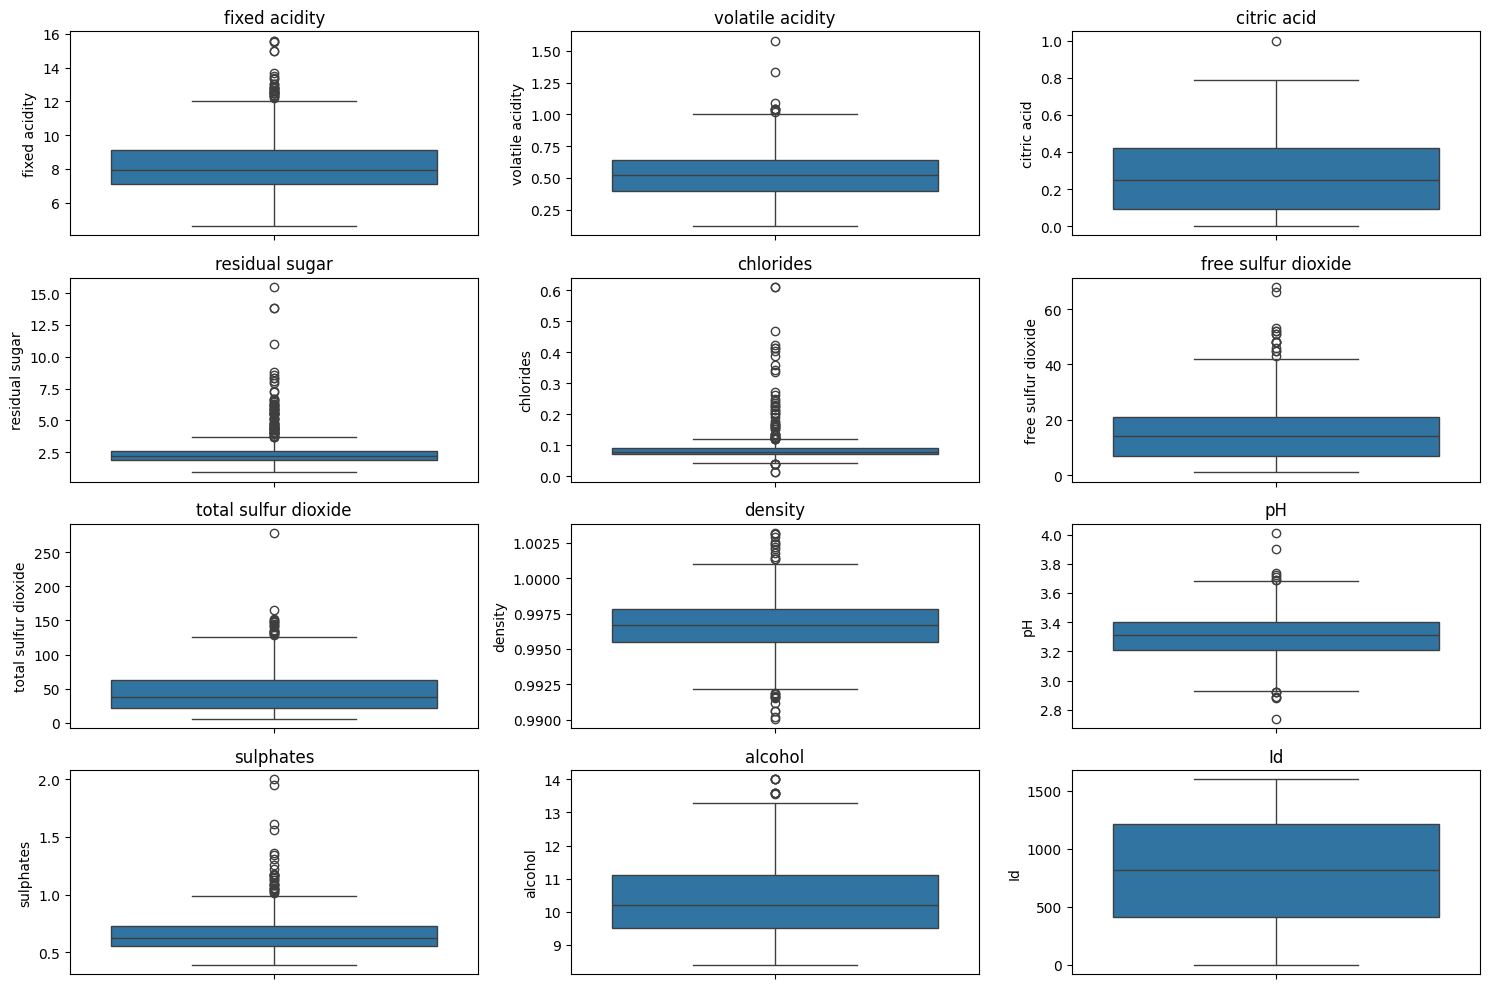

In [ ]:
plt.figure(figsize=(15,10))
for i, col in enumerate(X.columns):
    plt.subplot(4,3,i+1)
    sns.boxplot(y=train[col])
    plt.title(col)

plt.tight_layout()
plt.show()

**Interpretasi**

Boxplot digunakan untuk mendeteksi outlier pada setiap variabel.

Outlier merupakan data ekstrem yang nilainya jauh berbeda dibanding data lainnya.

Pada dataset wine quality, beberapa outlier masih dapat dipertahankan karena kemungkinan merepresentasikan karakteristik wine tertentu.

Boxplot menunjukkan persebaran data, median, serta keberadaan outlier pada setiap fitur. Sebagian besar variabel memiliki banyak titik di luar whisker, yang menandakan adanya outlier dalam dataset.

Variabel seperti *residual sugar*, *chlorides*, *free sulfur dioxide*, *total sulfur dioxide*, dan *sulphates* memiliki jumlah outlier yang cukup banyak dan cenderung berada di sisi atas, sehingga distribusinya miring ke kanan. Variabel *volatile acidity* dan *alcohol* juga memiliki beberapa outlier bernilai tinggi.

Sementara itu, variabel *pH* dan *density* memiliki persebaran yang lebih stabil karena boxplot relatif simetris dan jumlah outlier lebih sedikit. Variabel *fixed acidity* dan *citric acid* memiliki beberapa outlier, tetapi tidak sebanyak variabel lainnya.

Secara keseluruhan, boxplot menunjukkan bahwa dataset mengandung cukup banyak outlier pada beberapa fitur. Oleh karena itu, pada tahap preprocessing dapat dipertimbangkan penanganan outlier, seperti trimming, winsorizing, atau normalisasi data agar hasil analisis dan pemodelan menjadi lebih optimal.


### **5.6 Korelasi terhadap Target Quality**

quality                 1.000000
alcohol                 0.473555
sulphates               0.260703
citric acid             0.221263
fixed acidity           0.092714
Id                      0.049030
residual sugar         -0.020511
pH                     -0.033199
free sulfur dioxide    -0.054509
chlorides              -0.144946
total sulfur dioxide   -0.172737
density                -0.207903
volatile acidity       -0.430059
Name: quality, dtype: float64


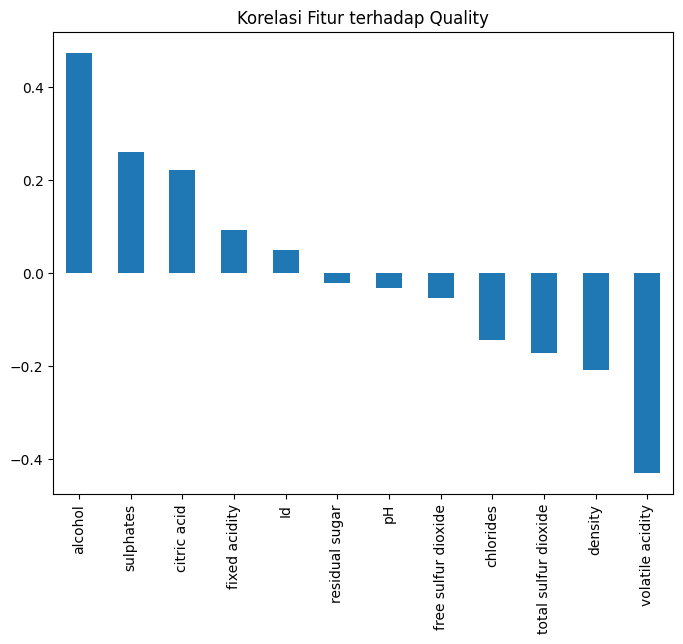

In [12]:
corr_quality = train.corr()['quality'].sort_values(ascending=False)
print(corr_quality)
plt.figure(figsize=(8,6))
corr_quality.drop('quality').plot(kind='bar')
plt.title('Korelasi Fitur terhadap Quality')
plt.show()

**Interpretasi**

Visualisasi ini menunjukkan fitur yang paling mempengaruhi kualitas wine.

Fitur dengan korelasi positif tinggi cenderung meningkatkan quality, sedangkan fitur dengan korelasi negatif dapat menurunkan quality.

Grafik korelasi terhadap target *quality* menunjukkan tingkat hubungan setiap fitur dengan kualitas wine. Nilai korelasi positif berarti semakin tinggi nilai fitur maka kualitas wine cenderung meningkat, sedangkan korelasi negatif berarti semakin tinggi nilai fitur maka kualitas wine cenderung menurun.

Variabel yang memiliki korelasi positif tertinggi terhadap *quality* adalah *alcohol* sebesar 0,47, yang menunjukkan bahwa kadar alkohol memiliki pengaruh cukup kuat dalam meningkatkan kualitas wine. Selain itu, *sulphates* (0,26) dan *citric acid* (0,22) juga memiliki hubungan positif, meskipun pengaruhnya lebih lemah.

Sebaliknya, *volatile acidity* memiliki korelasi negatif paling besar sebesar -0,43, sehingga semakin tinggi kadar *volatile acidity*, kualitas wine cenderung menurun. Variabel lain seperti *density* (-0,21), *total sulfur dioxide* (-0,17), dan *chlorides* (-0,14) juga memiliki hubungan negatif terhadap kualitas, namun pengaruhnya relatif lemah.

Secara keseluruhan, fitur yang paling berpengaruh terhadap kualitas wine adalah *alcohol* dan *volatile acidity*, karena memiliki nilai korelasi paling besar dibandingkan fitur lainnya.


## **6. Pembuatan dan Evaluasi Model**
Pada penelitian ini digunakan beberapa model klasifikasi untuk dibandingkan performanya.

### **6.1 Logistic Regression**

In [ ]:
from sklearn.model_selection import cross_val_score

logreg = LogisticRegression(max_iter=500)
logreg.fit(X_train_scaled, y_train)

pred_logreg = logreg.predict(X_valid_scaled)

acc_logreg = accuracy_score(y_valid, pred_logreg)

# Calculate Cross-Validation score
cv_logreg = cross_val_score(logreg, X_train_scaled, y_train, cv=5, scoring='accuracy')

print('Accuracy Logistic Regression (Validation Set):', acc_logreg)
print('Accuracy Logistic Regression (CV Mean):', cv_logreg.mean())
print(classification_report(y_valid, pred_logreg))

Accuracy Logistic Regression (Validation Set): 0.6104651162790697
Accuracy Logistic Regression (CV Mean): 0.5912408759124087
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         5
           5       0.67      0.78      0.72        73
           6       0.55      0.60      0.58        68
           7       0.58      0.32      0.41        22
           8       0.00      0.00      0.00         3

    accuracy                           0.61       172
   macro avg       0.30      0.28      0.29       172
weighted avg       0.58      0.61      0.59       172



**Interpretasi Model Logistic Regression**

Berdasarkan hasil evaluasi, model Logistic Regression memperoleh accuracy sebesar 61,05% pada validation set dan rata-rata cross validation sebesar 59,12%, yang menunjukkan bahwa model memiliki performa yang cukup stabil dalam memprediksi kualitas wine. Model mampu melakukan prediksi dengan baik terutama pada kelas quality 5 dan 6 karena kedua kelas tersebut memiliki jumlah data paling banyak pada dataset. Namun, model masih kurang optimal dalam memprediksi kelas dengan jumlah data sedikit seperti quality 3, 4, dan 8, sehingga beberapa nilai precision dan recall masih bernilai 0. Secara keseluruhan, Logistic Regression cukup baik digunakan untuk klasifikasi kualitas wine, tetapi performanya masih terbatas pada data dengan distribusi kelas yang tidak seimbang dan pola hubungan yang kompleks.

### **6.2 Decision Tree**

In [ ]:
from sklearn.model_selection import cross_val_score

dt = DecisionTreeClassifier(
    max_depth=10,
    random_state=42
)

dt.fit(X_train, y_train)

pred_dt = dt.predict(X_valid)

acc_dt = accuracy_score(y_valid, pred_dt)

# Calculate Cross-Validation score
cv_dt = cross_val_score(dt, X_train, y_train, cv=5, scoring='accuracy')

print('Accuracy Decision Tree (Validation Set):', acc_dt)
print('Accuracy Decision Tree (CV Mean):', cv_dt.mean())
print(classification_report(y_valid, pred_dt))

Accuracy Decision Tree (Validation Set): 0.5523255813953488
Accuracy Decision Tree (CV Mean): 0.5547445255474452
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         5
           5       0.66      0.64      0.65        73
           6       0.55      0.56      0.55        68
           7       0.42      0.45      0.43        22
           8       0.00      0.00      0.00         3

    accuracy                           0.55       172
   macro avg       0.27      0.28      0.27       172
weighted avg       0.55      0.55      0.55       172



 **Interpretasi Model Decision Tree**

Berdasarkan hasil evaluasi, model Decision Tree memperoleh accuracy sebesar 55,23% pada validation set dan rata-rata cross validation sebesar 55,47%, yang menunjukkan bahwa performa model cukup stabil namun masih lebih rendah dibandingkan beberapa model lainnya. Model mampu melakukan prediksi cukup baik pada kelas quality 5 dan 6 karena jumlah datanya lebih dominan pada dataset. Namun, model masih kurang optimal dalam memprediksi kelas dengan jumlah data sedikit seperti quality 3, 4, dan 8 sehingga nilai precision, recall, dan f1-score pada beberapa kelas masih bernilai 0. Secara keseluruhan, Decision Tree cukup mampu mengenali pola pada data, tetapi model cenderung memiliki keterbatasan dalam menangani distribusi data yang tidak seimbang dan berpotensi mengalami overfitting pada data tertentu.


### **6.3 Random Forest**

In [13]:
from sklearn.model_selection import cross_val_score

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_valid)

acc_rf = accuracy_score(y_valid, pred_rf)

# Calculate Cross-Validation score
cv_rf = cross_val_score(rf, X_train, y_train, cv=5, scoring='accuracy')

print('Accuracy Random Forest (Validation Set):', acc_rf)
print('Accuracy Random Forest (CV Mean):', cv_rf.mean())
print(classification_report(y_valid, pred_rf))

Accuracy Random Forest (Validation Set): 0.5988372093023255
Accuracy Random Forest (CV Mean): 0.6072992700729927
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         5
           5       0.65      0.71      0.68        73
           6       0.55      0.62      0.58        68
           7       0.53      0.36      0.43        22
           8       1.00      0.33      0.50         3

    accuracy                           0.60       172
   macro avg       0.46      0.34      0.37       172
weighted avg       0.58      0.60      0.58       172



**Interpretasi Model Random Forest**

Berdasarkan hasil evaluasi, model Random Forest memperoleh accuracy sebesar 59,88% pada validation set dan rata-rata cross validation sebesar 60,73%, yang menunjukkan bahwa model memiliki performa yang cukup baik dan stabil dalam memprediksi kualitas wine. Model mampu melakukan prediksi dengan baik terutama pada kelas quality 5 dan 6 yang memiliki jumlah data paling banyak pada dataset. Selain itu, Random Forest menunjukkan performa yang lebih baik dibanding beberapa model lain dalam mengenali kelas quality 7 dan 8. Namun, model masih mengalami kesulitan dalam memprediksi kelas dengan jumlah data sangat sedikit seperti quality 3 dan 4 sehingga nilai precision dan recall pada kelas tersebut masih rendah. Secara keseluruhan, Random Forest mampu memberikan performa klasifikasi yang baik karena dapat menangani hubungan non-linear dan mengurangi overfitting melalui kombinasi banyak decision tree.


### **6.4 Gradient Boosting**

In [ ]:
from sklearn.model_selection import cross_val_score

gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    random_state=42
)

gb.fit(X_train, y_train)

pred_gb = gb.predict(X_valid)

acc_gb = accuracy_score(y_valid, pred_gb)

# Calculate Cross-Validation score
cv_gb = cross_val_score(gb, X_train, y_train, cv=5, scoring='accuracy')

print('Accuracy Gradient Boosting (Validation Set):', acc_gb)
print('Accuracy Gradient Boosting (CV Mean):', cv_gb.mean())
print(classification_report(y_valid, pred_gb))

Accuracy Gradient Boosting (Validation Set): 0.5755813953488372
Accuracy Gradient Boosting (CV Mean): 0.5912408759124087
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.50      0.20      0.29         5
           5       0.65      0.70      0.68        73
           6       0.52      0.57      0.55        68
           7       0.47      0.32      0.38        22
           8       0.50      0.33      0.40         3

    accuracy                           0.58       172
   macro avg       0.44      0.35      0.38       172
weighted avg       0.57      0.58      0.57       172



**Interpretasi Model Gradient Boosting**

Berdasarkan hasil evaluasi, model Gradient Boosting memperoleh accuracy sebesar 57,56% pada validation set dan rata-rata cross validation sebesar 59,12%, yang menunjukkan bahwa model memiliki performa yang cukup baik dan relatif stabil dalam memprediksi kualitas wine. Model mampu melakukan prediksi dengan baik terutama pada kelas quality 5 dan 6 yang merupakan kelas dengan jumlah data terbanyak pada dataset. Selain itu, model juga mulai mampu mengenali beberapa kelas minoritas seperti quality 4 dan 8 meskipun performanya masih terbatas. Namun, model masih mengalami kesulitan dalam memprediksi kelas dengan jumlah data sangat sedikit seperti quality 3 sehingga nilai precision dan recall pada kelas tersebut masih rendah. Secara keseluruhan, Gradient Boosting cukup baik dalam menangkap pola kompleks pada data, namun performanya masih sedikit di bawah Random Forest pada dataset yang digunakan.


### **6.5 K-Nearest Neighbor (KNN)**

In [ ]:
from sklearn.model_selection import cross_val_score

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

pred_knn = knn.predict(X_valid_scaled)

acc_knn = accuracy_score(y_valid, pred_knn)

# Calculate Cross-Validation score
cv_knn = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='accuracy')

print('Accuracy KNN (Validation Set):', acc_knn)
print('Accuracy KNN (CV Mean):', cv_knn.mean())
print(classification_report(y_valid, pred_knn))

Accuracy KNN (Validation Set): 0.48255813953488375
Accuracy KNN (CV Mean): 0.545985401459854
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         5
           5       0.54      0.59      0.56        73
           6       0.46      0.43      0.44        68
           7       0.48      0.50      0.49        22
           8       0.00      0.00      0.00         3

    accuracy                           0.48       172
   macro avg       0.25      0.25      0.25       172
weighted avg       0.47      0.48      0.48       172



**Interpretasi Model K-Nearest Neighbors**

Berdasarkan hasil evaluasi, model KNN memperoleh accuracy sebesar 48,26% pada validation set dan rata-rata cross validation sebesar 54,60%, yang menunjukkan bahwa performa model masih relatif rendah dibandingkan model lainnya dalam memprediksi kualitas wine. Model cukup mampu melakukan prediksi pada kelas quality 5, 6, dan 7, namun masih kesulitan dalam mengenali kelas dengan jumlah data sedikit seperti quality 3, 4, dan 8 sehingga beberapa nilai precision dan recall masih bernilai 0. Perbedaan nilai validation accuracy dan cross validation menunjukkan bahwa performa model kurang stabil pada berbagai pembagian data. Secara keseluruhan, KNN dapat digunakan untuk klasifikasi kualitas wine, tetapi performanya masih kurang optimal dibandingkan model ensemble seperti Random Forest dan Gradient Boosting.


### **6.6 Cross Validation**

In [ ]:
from sklearn.model_selection import cross_val_score

# Logistic Regression
cv_logreg = cross_val_score(
    logreg,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='accuracy'
)

# Decision Tree
cv_dt = cross_val_score(
    dt,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy'
)

# Random Forest
cv_rf = cross_val_score(
    rf,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy'
)

# Gradient Boosting
cv_gb = cross_val_score(
    gb,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy'
)

# KNN
cv_knn = cross_val_score(
    knn,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='accuracy'
)

# Membuat tabel hasil cross validation
cv_results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'Gradient Boosting',
        'KNN'
    ],
    'CV Mean Accuracy': [
        cv_logreg.mean(),
        cv_dt.mean(),
        cv_rf.mean(),
        cv_gb.mean(),
        cv_knn.mean()
    ]
})

# Mengurutkan hasil dari yang terbaik
cv_results = cv_results.sort_values(
    by='CV Mean Accuracy',
    ascending=False
)

cv_results

,Model,CV Mean Accuracy
2,Random Forest,0.607299
0,Logistic Regression,0.591241
3,Gradient Boosting,0.591241
1,Decision Tree,0.554745
4,KNN,0.545985


**Interpretasi Cross-validation**

Berdasarkan hasil cross validation, model Random Forest memperoleh nilai rata-rata accuracy tertinggi sebesar 0,6073 dibandingkan model lainnya, sehingga menunjukkan bahwa Random Forest memiliki performa paling baik dan stabil dalam memprediksi kualitas wine. Logistic Regression dan Gradient Boosting memperoleh nilai accuracy yang sama yaitu sebesar 0,5912, sedangkan Decision Tree dan KNN memiliki performa yang lebih rendah. Hasil ini menunjukkan bahwa model ensemble seperti Random Forest lebih mampu menangani pola data yang kompleks dan memberikan kemampuan generalisasi yang lebih baik pada dataset wine quality.


### **6.7 Hyperparameter Tuning**

**6.7.1 Logistic Regression**

In [ ]:
from sklearn.model_selection import GridSearchCV

param_logreg = {
    'C': [0.01, 0.1, 1, 10]
}

grid_logreg = GridSearchCV(
    LogisticRegression(max_iter=500),
    param_logreg,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid_logreg.fit(X_train_scaled, y_train)

print('Best Logistic Regression Parameters :',
      grid_logreg.best_params_)

print('Best Logistic Regression Accuracy :',
      grid_logreg.best_score_)

Best Logistic Regression Parameters : {'C': 1}
Best Logistic Regression Accuracy : 0.5912050869531909


**6.7.2 Decision Tree**

In [ ]:
param_dt = {
    'max_depth': [3, 5, 10],
    'min_samples_split': [2, 5, 10]
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_dt,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid_dt.fit(X_train, y_train)

print('Best Decision Tree Parameters :',
      grid_dt.best_params_)

print('Best Decision Tree Accuracy :',
      grid_dt.best_score_)

Best Decision Tree Parameters : {'max_depth': 5, 'min_samples_split': 5}
Best Decision Tree Accuracy : 0.5591051865471539


**6.7.3 Random Forest**

In [ ]:
param_rf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_rf,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print('Best Random Forest Parameters :',
      grid_rf.best_params_)

print('Best Random Forest Accuracy :',
      grid_rf.best_score_)

Best Random Forest Parameters : {'max_depth': None, 'n_estimators': 200}
Best Random Forest Accuracy : 0.6043629816900329


**6.7.4 Gradient Boosting**

In [ ]:
param_gb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5]
}

grid_gb = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_gb,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid_gb.fit(X_train, y_train)

print('Best Gradient Boosting Parameters :',
      grid_gb.best_params_)

print('Best Gradient Boosting Accuracy :',
      grid_gb.best_score_)

Best Gradient Boosting Parameters : {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
Best Gradient Boosting Accuracy : 0.5926989963992952


**6.7.5 KNN**

In [ ]:
param_knn = {
    'n_neighbors': [3, 5, 7, 9]
}

grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_knn,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid_knn.fit(X_train_scaled, y_train)

print('Best KNN Parameters :',
      grid_knn.best_params_)

print('Best KNN Accuracy :',
      grid_knn.best_score_)

Best KNN Parameters : {'n_neighbors': 5}
Best KNN Accuracy : 0.532840470900687


**Interpretasi**

Hyperparameter tuning dilakukan untuk mencari kombinasi parameter terbaik.

Proses ini membantu meningkatkan performa model sehingga memperoleh accuracy yang lebih optimal.

Hyperparameter tuning dilakukan menggunakan GridSearchCV dengan 3-fold cross validation untuk memperoleh kombinasi parameter terbaik pada masing-masing model. Hasil tuning menunjukkan bahwa:
1. Logistic Regression mencapai performa optimal pada parameter C = 1 dengan akurasi 0.5912,
2. Decision Tree pada max_depth = 5 dan min_samples_split = 5 dengan akurasi 0.5591,
3. Random Forest pada n_estimators = 200 dan max_depth = None dengan akurasi tertinggi sebesar 0.6044,
4. Gradient Boosting pada learning_rate = 0.05, max_depth = 3, dan n_estimators = 100 dengan akurasi 0.5927, serta
5. KNN pada n_neighbors = 5 dengan akurasi 0.5328.

Secara keseluruhan, Random Forest memberikan performa terbaik dibandingkan model lainnya, yang menunjukkan bahwa pendekatan ensemble lebih efektif dalam menangkap pola data dan menghasilkan generalisasi yang lebih baik pada dataset yang digunakan.


## **7. Perbandingan Akurasi Model**

In [ ]:
hasil_model = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'Gradient Boosting',
        'KNN'
    ],
    'Accuracy': [
        cv_logreg.mean(), # Using cross-validation mean
        cv_dt.mean(),     # Using cross-validation mean
        cv_rf.mean(),     # Using cross-validation mean
        cv_gb.mean(),     # Using cross-validation mean
        cv_knn.mean()     # Using cross-validation mean
    ]
})

,Model,Accuracy
0,Logistic Regression,0.591241
1,Decision Tree,0.554745
2,Random Forest,0.607299
3,Gradient Boosting,0.591241
4,KNN,0.545985


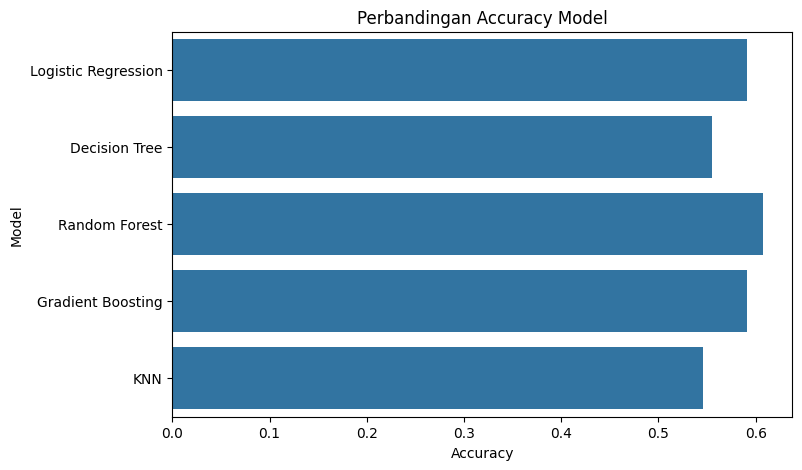

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

display(hasil_model)
plt.figure(figsize=(8,5))
sns.barplot(x='Accuracy', y='Model', data=hasil_model)
plt.title('Perbandingan Accuracy Model')
plt.show()

### **7.1 Kesimpulan Perbandingan Model**

In [ ]:
hasil_model = hasil_model.sort_values(by='Accuracy', ascending=False)
hasil_model

,Model,Accuracy
2,Random Forest,0.607299
0,Logistic Regression,0.591241
3,Gradient Boosting,0.591241
1,Decision Tree,0.554745
4,KNN,0.545985


**Interpretasi**

Berdasarkan hasil perbandingan nilai akurasi dari masing-masing model, diperoleh bahwa **Random Forest** memiliki performa terbaik dengan akurasi sebesar **0.6073**, sehingga menjadi model yang paling optimal dalam melakukan klasifikasi pada dataset ini. Selanjutnya, **Logistic Regression** dan **Gradient Boosting** menunjukkan hasil yang sama, yaitu **0.5912**, yang mengindikasikan bahwa kedua model memiliki kemampuan yang relatif sebanding dalam mempelajari pola data, meskipun masih berada di bawah Random Forest. Sementara itu, **Decision Tree** memperoleh akurasi sebesar **0.5547** dan **KNN** sebesar **0.5460**, yang menunjukkan performa yang lebih rendah dibandingkan model lainnya. Secara keseluruhan, model berbasis ensemble, khususnya Random Forest, memberikan hasil terbaik karena mampu menangkap pola data yang lebih kompleks dan menghasilkan generalisasi yang lebih baik dibandingkan model lainnya.


## **8. Pemilihan Model Terbaik**

In [ ]:
hasil_model.sort_values(by='Accuracy', ascending=False)

,Model,Accuracy
2,Random Forest,0.607299
0,Logistic Regression,0.591241
3,Gradient Boosting,0.591241
1,Decision Tree,0.554745
4,KNN,0.545985


**Interpretasi**

Berdasarkan hasil evaluasi, model dengan accuracy tertinggi dipilih sebagai model akhir, yaitu Random Forest dengan nilai accuracy sebesar 0.6073. Oleh karena itu, model Random Forest digunakan untuk melakukan prediksi pada data testing.

Alasan pemilihan Random Forest adalah sebagai berikut: memiliki accuracy paling tinggi dibandingkan model lainnya, mampu menangani pola data yang kompleks melalui kombinasi banyak decision tree, serta memiliki sifat ensemble yang dapat mengurangi risiko overfitting dan meningkatkan generalisasi model. Selain itu, Random Forest juga cocok digunakan pada data tabular karena mampu bekerja dengan baik tanpa asumsi distribusi data yang ketat.

### **8.1 Koefisien Feature Importance**

In [ ]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

# Mengurutkan feature importance
importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance

,Feature,Importance
10,alcohol,0.119924
9,sulphates,0.116754
1,volatile acidity,0.107280
6,total sulfur dioxide,0.088279
4,chlorides,0.078890
11,Id,0.076528
7,density,0.075773
2,citric acid,0.073206
0,fixed acidity,0.071375
8,pH,0.067305


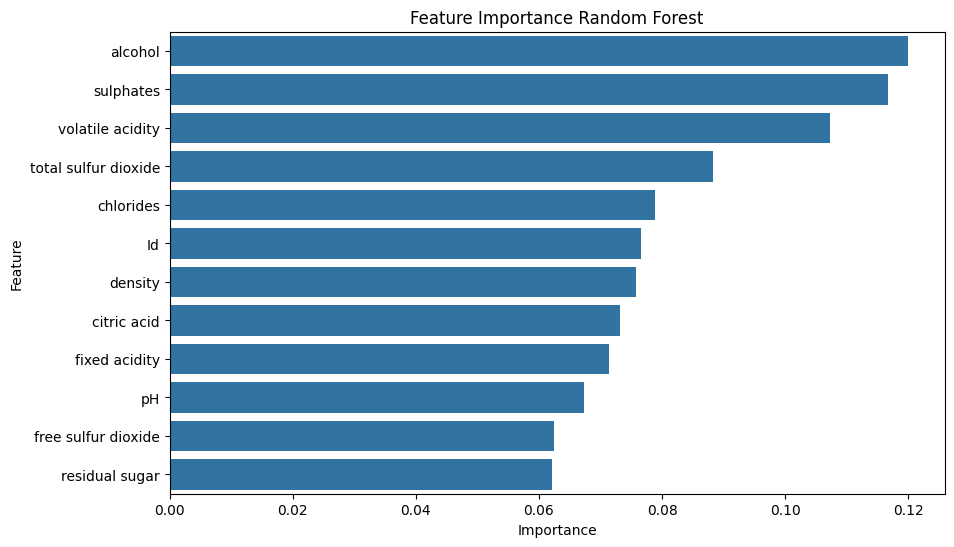

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title('Feature Importance Random Forest')
plt.show()

**Interpretasi**

Berdasarkan hasil feature importance, variabel yang paling berpengaruh terhadap model adalah alcohol (0,119924), diikuti sulphates (0,116754) dan volatile acidity (0,107280). Hal ini menunjukkan bahwa ketiga variabel tersebut memiliki kontribusi terbesar dalam menentukan hasil prediksi.

Variabel lain seperti total sulfur dioxide, chlorides, density, citric acid, fixed acidity, pH, free sulfur dioxide, residual sugar, dan Id memiliki nilai importance yang lebih rendah (sekitar 0,06–0,09), sehingga pengaruhnya terhadap model relatif lebih kecil.

Secara keseluruhan, model paling dipengaruhi oleh karakteristik kimia utama terutama kadar alkohol, sulphates, dan volatile acidity.


## **9. Confusion Matrix Model Terbaik**

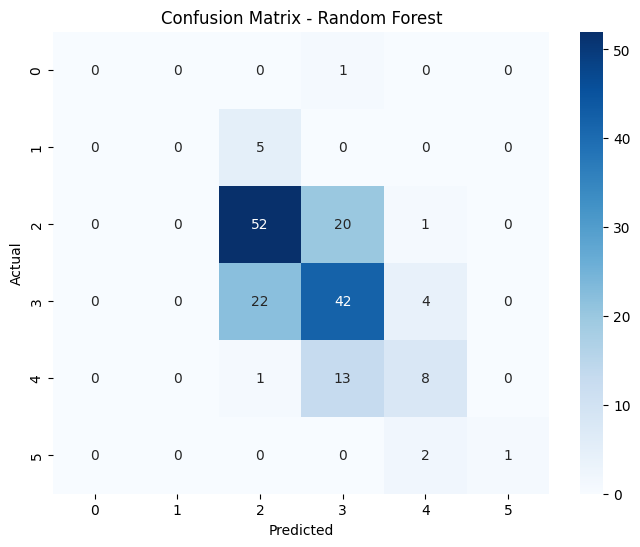

In [21]:
cm = confusion_matrix(y_valid, pred_rf)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

**Interpretasi**

Confusion matrix digunakan untuk melihat:

jumlah prediksi benar,
jumlah kesalahan klasifikasi,
dan performa model pada setiap kelas.

Semakin banyak nilai diagonal utama, maka model semakin baik dalam melakukan prediksi.

Berdasarkan matriks konfusi, model Random Forest yang digunakan telah berhasil menunjukkan kemampuan klasifikasi yang cukup solid, terutama pada kelompok data yang paling dominan. Model ini memiliki akurasi tertinggi pada Kelas 3 dan Kelas 2, di mana mayoritas sampel berhasil diprediksi tepat pada targetnya (42 dan 20 prediksi benar). Keberhasilan ini menunjukkan bahwa model sudah mampu mengenali fitur-fitur utama dari kategori yang memiliki data representatif.

Meskipun terdapat beberapa misclassification pada kelas minoritas, hal ini wajar terjadi pada model klasifikasi awal dan memberikan wawasan berharga untuk pengembangan selanjutnya. Secara keseluruhan, model telah menunjukkan potensi yang kuat dalam membedakan tren data utama, dan dengan penyesuaian skala data di masa mendatang, performa ini dapat ditingkatkan menjadi lebih optimal di seluruh kategori.

## **10. Prediksi Data Testing**

In [15]:
# Menggunakan Random Forest sebagai model terbaik
final_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

# Training ulang menggunakan seluruh data training, pastikan 'Id' dihapus dari X
# X sudah didefinisikan sebagai train.drop('quality', axis=1) yang masih mengandung 'Id'
# Kita perlu menghilangkan 'Id' dari X sebelum fitting
final_model.fit(X.drop('Id', axis=1), y)

# Menyiapkan data testing tanpa kolom Id
X_test = test.drop('Id', axis=1)

# Prediksi quality
pred_test = final_model.predict(X_test)

# Menampilkan hasil prediksi
print(pred_test)

[5 6 5 5 5 6 5 5 6 5 7 6 6 6 5 5 6 6 5 7 6 6 5 7 5 5 7 6 5 6 5 6 7 6 5 5 6
 6 6 6 6 6 6 5 5 5 5 6 5 6 7 5 6 7 6 7 6 6 6 5 5 6 6 6 6 6 6 5 5 5 7 6 5 6
 5 5 5 6 5 6 5 6 6 5 5 6 5 5 6 6 5 6 5 5 5 5 5 6 6 5 6 6 5 6 5 5 6 6 6 7 7
 5 5 6 5 5 6 6 6 5 5 5 5 6 5 5 6 6 5 6 5 5 7 6 7 5 5 5 5 6 7 5 5 5 6 5 5 5
 5 5 6 5 6 5 6 5 5 5 7 6 5 5 6 6 7 5 6 6 6 5 6 5 5 5 5 5 7 6 6 5 6 5 6 5 5
 5 6 5 6 5 6 6 7 6 6 6 5 6 7 6 6 6 5 6 7 7 5 5 6 6 5 6 6 6 5 6 6 5 7 5 5 6
 5 5 5 6 6 6 6 6 7 7 5 5 6 6 5 6 5 5 6 6 6 5 5 6 5 6 6 5 5 5 6 6 5 6 7 5 5
 5 5 6 7 6 5 5 6 6 5 6 6 7 5 6 5 6 5 6 5 5 5 6 5 5 5 7]


**Interpretasi Prediksi Data Testing**

Berdasarkan hasil prediksi pada data testing, model menghasilkan prediksi kualitas wine yang didominasi oleh kelas quality 5 dan quality 6. Hal ini menunjukkan bahwa sebagian besar wine pada dataset testing diperkirakan memiliki kualitas menengah hingga cukup baik.

Selain itu, terdapat beberapa data yang diprediksi memiliki quality 7, yang menunjukkan adanya wine dengan kualitas lebih baik dibandingkan mayoritas data lainnya. Tidak ditemukan prediksi pada quality 3, 4, maupun 8, yang menunjukkan bahwa kelas tersebut memiliki jumlah data yang sedikit sehingga model lebih sulit mengenali polanya.

Secara keseluruhan, hasil prediksi menunjukkan bahwa model Random Forest mampu melakukan klasifikasi kualitas wine dengan cukup baik berdasarkan pola karakteristik kimiawi pada dataset.


## **11. Membuat File Submission CSV**

In [18]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier

# Menggunakan Random Forest sebagai model terbaik
final_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

# Training ulang menggunakan seluruh data training, pastikan 'Id' dihapus dari X
# X dan y diasumsikan sudah didefinisikan di sel sebelumnya (zFe5YW7GBbJ-)
final_model.fit(X.drop('Id', axis=1), y)

# Menyiapkan data testing tanpa kolom Id
X_test = test.drop('Id', axis=1)

# Prediksi quality
pred_test = final_model.predict(X_test)

# Membuat dataframe submission
submission = pd.DataFrame({
    'Id': test['Id'],
    'quality': pred_test
})

# Menampilkan 5 data pertama
submission.head()

,Id,quality
0,222,5
1,1514,6
2,417,5
3,754,5
4,516,5


**Interpretasi Hasil Submission**

Berdasarkan hasil submission, model berhasil memprediksi nilai quality untuk setiap data pada dataset testing. Kolom Id digunakan sebagai identitas masing-masing data, sedangkan kolom quality menunjukkan hasil prediksi kualitas wine yang dihasilkan oleh model Random Forest.

Pada beberapa data awal terlihat bahwa sebagian besar wine diprediksi memiliki quality 5 dan 6, yang menunjukkan bahwa mayoritas wine pada dataset testing memiliki kualitas menengah hingga cukup baik. Hasil ini sesuai dengan distribusi data pada dataset training yang juga didominasi oleh kelas quality 5 dan 6.

## **12. Menyimpan File CSV**

In [19]:
# Menyimpan hasil prediksi ke CSV
submission.to_csv(
    'hasilprediksi_3NIMterakhir.csv',
    index=False
)

## **13. Download File CSV**

In [20]:
from google.colab import files

files.download('hasilprediksi_3NIMterakhir.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## **14. Kesimpulan**


Berdasarkan seluruh proses analisis data mining yang telah dilakukan, mulai dari preprocessing data, eksplorasi data, pembuatan model, evaluasi model, hingga prediksi data testing, diperoleh hasil bahwa setiap model klasifikasi memiliki performa yang berbeda-beda dalam memprediksi kualitas wine.

Hasil evaluasi menggunakan cross validation menunjukkan bahwa model Random Forest memperoleh nilai rata-rata accuracy tertinggi dibandingkan model lainnya, sehingga dipilih sebagai model terbaik pada penelitian ini. Random Forest mampu memberikan performa yang lebih stabil dan memiliki kemampuan generalisasi yang baik dalam mengenali pola data kualitas wine.

Selain itu, hasil classification report menunjukkan bahwa model mampu memprediksi kelas quality 5 dan 6 dengan cukup baik karena kedua kelas tersebut memiliki jumlah data paling dominan pada dataset. Namun, model masih mengalami kesulitan dalam memprediksi kelas dengan jumlah data sedikit seperti quality 3, 4, dan 8 karena distribusi data yang tidak seimbang.

Selanjutnya, model terbaik digunakan untuk memprediksi data testing dan berhasil menghasilkan file submission sesuai format yang diminta. Dengan demikian, dapat disimpulkan bahwa metode Random Forest efektif digunakan untuk klasifikasi kualitas wine berdasarkan karakteristik kimiawi yang terdapat pada dataset.
